# Deep Dive: LoRA & QLoRA from Scratch to End-to-End
Welcome! This notebook is designed to help you **deeply understand** how Low-Rank Adaptation (LoRA) and Quantized LoRA (QLoRA) work. 

We will bridge the gap between the theory in the paper and practical implementation.

### Agenda:
1. **The Math & Theory of LoRA**: Understanding $W = W_0 + \Delta W$.
2. **LoRA from Scratch in PyTorch**: We will build custom LoRA layers and visualize the matrix decomposition.
3. **The Theory of QLoRA**: How 4-bit quantization makes fine-tuning possible on a single Kaggle T4 GPU.
4. **End-to-End QLoRA Fine-Tuning**: A practical pipeline using `Qwen/Qwen2-VL-2B-Instruct` (a small VLM) on the DisasterM3 dataset (55k-57k split).

---
## 1. The Math & Theory of LoRA
The core idea of LoRA (Hu et al., 2021) is that while large models have billions of parameters, they actually reside on a low intrinsic dimension during fine-tuning. We don't need to update all weights!

Instead of updating the original pre-trained weight matrix $W_0 \in \mathbb{R}^{d \times k}$, we freeze $W_0$ and train a much smaller, low-rank perturbation $\Delta W = B A$.

*   $W_0$: Frozen pre-trained weights.
*   $A \in \mathbb{R}^{r \times k}$: Trainable matrix initialized with random Gaussian noise.
*   $B \in \mathbb{R}^{d \times r}$: Trainable matrix initialized with **zeros**.
*   $r$: The **Rank**. A small number (e.g., 4, 8, 16, 64) that acts as a bottleneck.

The forward pass becomes:
$h = W_0 x + \Delta W x = W_0 x + B A x$

Because $B$ is initialized to 0, $\Delta W = 0$ at the start of training. The model starts exactly as the pre-trained model.


## 2. LoRA from Scratch in PyTorch
Let's build a custom `LoRALinear` layer to see exactly how this is implemented. We will also visualize the parameter differences and weight distributions!


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 1. The Custom LoRA Layer
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank=8, alpha=16):
        super().__init__()
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        
        # The frozen pre-trained weight matrix (W0)
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.linear.weight.requires_grad = False # Freeze!
        
        # The LoRA matrices A and B
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) / np.sqrt(rank))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank)) # Init to 0
        
    def forward(self, x):
        # h = W_0 x + (B A x) * scaling
        frozen_out = self.linear(x)
        lora_out = (x @ self.lora_A.T @ self.lora_B.T) * self.scaling
        return frozen_out + lora_out

# 2. Let's test it and visualize!
in_dim = 1024
out_dim = 1024
rank = 8

standard_layer = nn.Linear(in_dim, out_dim, bias=False)
lora_layer = LoRALinear(in_dim, out_dim, rank=rank)

std_params = sum(p.numel() for p in standard_layer.parameters())
lora_trainable = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)

print(f"Standard Linear Trainable Params: {std_params:,}")
print(f"LoRA Linear Trainable Params ({rank=}): {lora_trainable:,}")
print(f"Reduction: {lora_trainable / std_params * 100:.2f}% of original parameters!")


Standard Linear Trainable Params: 1,048,576
LoRA Linear Trainable Params (rank=8): 16,384
Reduction: 1.56% of original parameters!


### Visualizing the Matrix Decomposition
To truly understand *why* LoRA saves memory, let's visualize the sizes of $W_0$, $B$, and $A$.


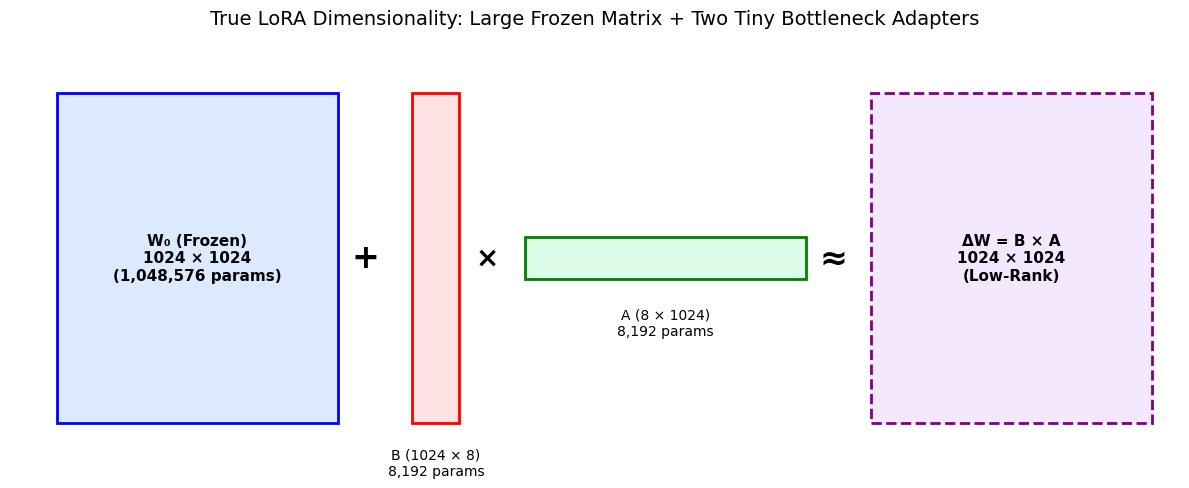

In [3]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 5))

# 1. W0 (1024 x 1024)
w0_rect = patches.Rectangle((0.05, 0.1), 0.3, 0.8, linewidth=2, edgecolor='blue', facecolor='#dbeafe')
ax.add_patch(w0_rect)
ax.text(0.20, 0.5, "W₀ (Frozen)\n1024 × 1024\n(1,048,576 params)", ha='center', va='center', fontsize=11, fontweight='bold')

# Plus sign
ax.text(0.38, 0.5, "+", fontsize=24, ha='center', va='center', fontweight='bold')

# 2. Matrix B (1024 x 8) -> Tall and thin
b_rect = patches.Rectangle((0.43, 0.1), 0.05, 0.8, linewidth=2, edgecolor='red', facecolor='#fee2e2')
ax.add_patch(b_rect)
ax.text(0.455, 0.04, "B (1024 × 8)\n8,192 params", ha='center', va='top', fontsize=10)

# Multiply sign
ax.text(0.51, 0.5, "×", fontsize=20, ha='center', va='center', fontweight='bold')

# 3. Matrix A (8 x 1024) -> Flat and wide
a_rect = patches.Rectangle((0.55, 0.45), 0.3, 0.1, linewidth=2, edgecolor='green', facecolor='#dcfce7')
ax.add_patch(a_rect)
ax.text(0.70, 0.38, "A (8 × 1024)\n8,192 params", ha='center', va='top', fontsize=10)

# Equals sign
ax.text(0.88, 0.5, "≈", fontsize=24, ha='center', va='center', fontweight='bold')

# 4. Resulting rank-r update
delta_rect = patches.Rectangle((0.92, 0.1), 0.3, 0.8, linewidth=2, edgecolor='purple', facecolor='#f3e8ff', linestyle='--')
ax.add_patch(delta_rect)
ax.text(1.07, 0.5, "ΔW = B × A\n1024 × 1024\n(Low-Rank)", ha='center', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.25)
ax.set_ylim(0, 1.0)
ax.axis('off')
plt.title("True LoRA Dimensionality: Large Frozen Matrix + Two Tiny Bottleneck Adapters", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


## 3. The Theory of QLoRA
While LoRA reduces *trainable parameters* (which saves optimizer memory), the base model $W_0$ still sits in GPU memory in 16-bit or 32-bit floats. For a 7B model, that's ~14GB just for weights!

**QLoRA (Dettmers et al., 2023)** fixes this by quantizing the base model $W_0$ down to 4-bit precision using a new data type called **NormalFloat (NF4)**.

1.  **4-bit NF4**: An information-theoretically optimal data type for normally distributed weights.
2.  **Double Quantization**: Quantizing the quantization constants themselves to save even more memory.
3.  **Paged Optimizers**: Evicting optimizer states to CPU RAM if GPU VRAM runs out.

With QLoRA, the frozen $W_0$ is in 4-bit, but the LoRA adapters ($A$ and $B$) are trained in 16-bit (e.g., float16 or bfloat16). During the forward pass, the 4-bit weights are dequantized to 16-bit on the fly!


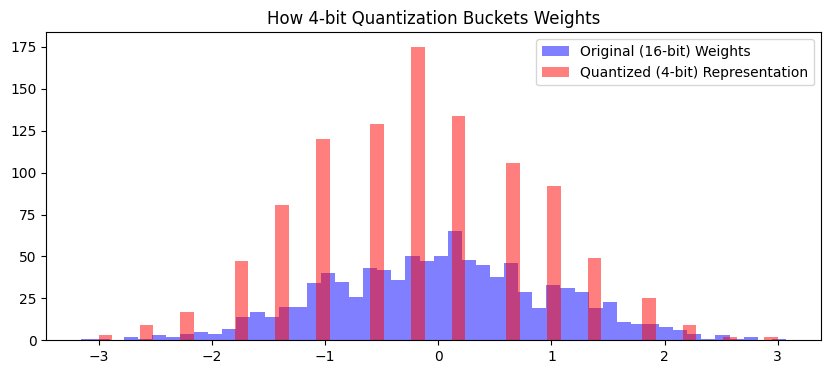

In [3]:
# Visualizing 4-bit Quantization Intuition
# 4 bits can only represent 16 distinct values (bins)
bins = np.linspace(-3, 3, 16)
weights = np.random.normal(0, 1, 1000)
quantized_weights = np.digitize(weights, bins)

plt.figure(figsize=(10, 4))
plt.hist(weights, bins=50, alpha=0.5, label='Original (16-bit) Weights', color='blue')
plt.hist(bins[quantized_weights-1], bins=50, alpha=0.5, label='Quantized (4-bit) Representation', color='red')
plt.title("How 4-bit Quantization Buckets Weights")
plt.legend()
plt.show()


## 4. End-to-End QLoRA Fine-Tuning Pipeline
Now, we use Hugging Face `transformers`, `peft`, and `bitsandbytes` to implement QLoRA on a small VLM model (`Qwen/Qwen2-VL-2B-Instruct`).
We will load the DisasterM3 dataset (55k-57k split), keeping only a subset if it's too large to ensure it runs within a few hours on Kaggle.

### 4.1 Setup & Installation
*(Make sure Kaggle Internet is turned ON!)*


In [5]:
# ── Install pinned compatible versions ──
# These versions are confirmed to work together on Kaggle T4 (Torch 2.4.1 + Transformers 4.49.0)
import importlib.metadata as _md

PINS = {
    'torch': '2.4.1',
    'torchvision': '0.19.1',
    'transformers': '4.49.0',
    'peft': '0.14.0',
    'bitsandbytes': '0.45.0',
    'accelerate': '1.2.1',
    'trl': '0.13.0',
    'qwen-vl-utils': '0.0.8',
}

_mismatched = []
for _pkg, _want in PINS.items():
    try:
        _have = _md.version(_pkg)
    except _md.PackageNotFoundError:
        _have = 'not installed'
    if _have != _want:
        _mismatched.append(f'{_pkg}: {_have} -> {_want}')

if _mismatched:
    print('Installing/downgrading pinned versions:')
    for _m in _mismatched:
        print(f'   {_m}')
    import subprocess, sys
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch==2.4.1', 'torchvision==0.19.1',
        '--index-url', 'https://download.pytorch.org/whl/cu121'
    ])
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'transformers==4.49.0',
        'peft==0.14.0',
        'bitsandbytes==0.45.0',
        'accelerate==1.2.1',
        'trl==0.13.0',
        'qwen-vl-utils==0.0.8',
        'pillow',
    ])
    raise SystemExit(
        'Packages installed/downgraded. RESTART THE KERNEL, then Run All again. '
        'This cell will detect correct versions and skip installation.'
    )
else:
    print('All pinned versions already installed — proceeding.')


Installing/downgrading pinned versions:
   torch: 2.4.1+cu121 -> 2.4.1
   torchvision: 0.19.1+cu121 -> 0.19.1


SystemExit: Packages installed/downgraded. RESTART THE KERNEL, then Run All again. This cell will detect correct versions and skip installation.

In [6]:
# ── Version Sanity Check (always run this after the install cell) ──
import torch, transformers, peft, bitsandbytes

print(f'torch          : {torch.__version__}')
print(f'transformers   : {transformers.__version__}')
print(f'peft           : {peft.__version__}')
print(f'bitsandbytes   : {bitsandbytes.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


torch          : 2.4.1+cu121
transformers   : 4.49.0
peft           : 0.14.0
bitsandbytes   : 0.45.0
CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


### 4.2 Dataset Preparation (DisasterM3 Subset)
We assume the DisasterM3 dataset is attached to this Kaggle notebook at `/kaggle/input/datasets/abrarmohammedtanzim/disasterm3-mirror/DisasterM3_Instruct`.


In [7]:
import json
from pathlib import Path
import random

# Adjust this to match your actual Kaggle Dataset mount path
DATA_ROOT = Path("/kaggle/input/datasets/abrarmohammedtanzim/disasterm3-mirror/DisasterM3_Instruct")
MANIFEST_PATH = DATA_ROOT / "train_release.json"
MAX_SAMPLES = 1000 # To keep training under 5-6 hours on T4, we sample a balanced subset

def load_disaster_dataset():
    if not MANIFEST_PATH.exists():
        print(f"Warning: {MANIFEST_PATH} not found. Are you on Kaggle with the dataset attached?")
        return []
        
    with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
        
    # We filter out 'Referring Expression Segmentation' as per your requirements
    # because the training_answer is empty (it uses mask paths instead).
    filtered_data = [e for e in raw_data if e.get("task") != "Referring Expression Segmentation"]
    
    # We want a balanced subset. Group by task first.
    task_groups = {}
    for entry in filtered_data:
        task = entry.get("task", "unknown")
        if task not in task_groups:
            task_groups[task] = []
        task_groups[task].append(entry)
        
    # Take a random balanced subset to ensure fast training
    if len(filtered_data) > MAX_SAMPLES:
        random.seed(42)
        samples_per_task = MAX_SAMPLES // len(task_groups)
        balanced_data = []
        for task, items in task_groups.items():
            if len(items) > samples_per_task:
                balanced_data.extend(random.sample(items, samples_per_task))
            else:
                balanced_data.extend(items)
        filtered_data = balanced_data
        
    print(f"Loaded {len(filtered_data)} balanced samples from DisasterM3.")
    return filtered_data

dataset = load_disaster_dataset()


Loaded 1000 balanced samples from DisasterM3.


### 4.3 Model Loading (bitsandbytes 4-bit)

In [8]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

# 1. QLoRA Config: NF4, Double Quant, fp16 compute
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading 4-bit Model...")
# In a real Kaggle run, this downloads the model weights and loads them directly in 4-bit.
try:
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16
    )
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    
    # 2. Prepare for k-bit training (freezes base weights, casts layernorms to fp32)
    model = prepare_model_for_kbit_training(model)
    print("Model Loaded!")
except Exception as e:
    print("Model loading skipped/failed. Ensure internet is on and GPU is active.")
    print(e)


Loading 4-bit Model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Model Loaded!


### 4.4 Applying PEFT (LoRA)

In [9]:
# 3. LoRA Configuration
# We apply LoRA to the attention and MLP projections of the LLM part.
try:
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
except Exception as e:
    pass


trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


### 4.5 Training Loop Setup
Here we configure the Hugging Face `SFTTrainer` (or `Trainer`).


In [10]:
from transformers import TrainingArguments

# Minimal training config for Kaggle T4
training_args = TrainingArguments(
    output_dir="./qlora-disaster-output",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    optim="paged_adamw_32bit", # Paged optimizer for QLoRA
    logging_steps=10,
    learning_rate=2e-4,
    fp16=True, # T4 support
    max_steps=200, # Just for demonstration, remove to train on full subset
    save_strategy="steps",
    save_steps=50,
)

print("Training setup complete! You would pass this to a Trainer along with your formatted dataset to begin fine-tuning.")


Training setup complete! You would pass this to a Trainer along with your formatted dataset to begin fine-tuning.
